In [1]:
from calendar import month_name

import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def fetch_gbif_data(species_list, year):
    """
    Takes a list and integer as parameters
    Returns a DataFrame of results from API of URL with parameters
    """
    url = "https://api.gbif.org/v1/occurrence/search"                   # string of URL, without parameters
    info = []
    min_cols = ["species", "decimalLatitude", "decimalLongitude",
                 "eventDate", "month", "stateProvince", "country",
                "coordinateUncertaintyInMeters", ]                      # Defines a list of minimum required columns to include in the DataFrame
    for a in range(len(species_list)):                                  # For a in range length of inputted list "species_list"
        for month in range(1, 13):                                      # For each iteration through the number of months
            parameters = {"decimalLatitude": "38.8,47.5",
                            "decimalLongitude": "-77.5,-66.5",
                            "year": year,
                            "scientificName": species_list[a],
                            "limit": 25,
                            "month": month}                             # Defines parameters to attach to URL
            response = requests.get(url, params=parameters)             # Sends GET request for URL with parameters
            data = response.json()                                      # Defines data as the decoded JSON response
            for b in data["results"]:                                   # For each category/parameter in the results of data
                info.append(b)                                          # Append to the list every value set in each iteration of results
    species_df = pd.DataFrame(info)                                     # Create a DataFrame from the list of results
    species_df = species_df[min_cols]                                   # Redefine "species_df" DataFrame with specified columns
    return species_df

In [3]:
generic_name = ["European Starling", "Great Blue Heron", "Northern Cardinal"]
sci_name = ["Sturnus_vulgaris", "Ardea_herodias", "Cardinalis_cardinalis"]
df = fetch_gbif_data(sci_name, 2023)
df

,species,decimalLatitude,decimalLongitude,eventDate,month,stateProvince,country,coordinateUncertaintyInMeters
0,Sturnus vulgaris,40.211020,-74.932472,2023-01-02T15:20,1,Pennsylvania,United States of America,15.0
1,Sturnus vulgaris,41.248763,-70.116340,2023-01-01T11:50,1,Massachusetts,United States of America,1001.0
2,Sturnus vulgaris,40.804230,-73.959533,2023-01-01T14:49:40,1,New York,United States of America,5.0
3,Sturnus vulgaris,38.887356,-77.019355,2023-01-01T15:06,1,District of Columbia,United States of America,8.0
4,Sturnus vulgaris,45.643203,-73.658449,2023-01-01T12:35,1,Québec,Canada,180.0
...,...,...,...,...,...,...,...,...
895,Cardinalis cardinalis,40.328742,-75.067331,2023-12-04T14:39:32,12,Pennsylvania,United States of America,12.0
896,Cardinalis cardinalis,40.770500,-73.952324,2023-12-05T11:34:02,12,New York,United States of America,35.0
897,Cardinalis cardinalis,42.396344,-71.149493,2023-12-04T15:22,12,Massachusetts,United States of America,8.0
898,Cardinalis cardinalis,40.328701,-75.067297,2023-12-04T15:27:51,12,Pennsylvania,United States of America,11.0


In [4]:
def clean_biodiversity_data(raw_df):
    """
    Takes a DataFrame
    Returns the inputted DataFrame with null/missing values and duplicate rows removed, as well as a dictionary of cleaning metrics
    """
    original_rcount = len(raw_df)                                       # Defines the number of rows for raw_df
    date = []
    for c in range(len(raw_df)):                                        # For each row/index number of raw_df
        date.append(raw_df["eventDate"].iloc[c].split("T")[0])          # Takes each entry of the "eventDate" column and splits the date and time,
                                                                        # Joined by "T", then appends only the date to the list "date"
    raw_df["eventDate"] = pd.DataFrame(date)                            # Replaces "eventDate" column values with date instead of date and time
    clean_df = raw_df.dropna()                                          # Defines new DataFrame without rows containing null/missing values
    null_drop = original_rcount - clean_df.shape[0]                     # Defines the number of null-valued rows dropped
    clean_df = clean_df.drop_duplicates()                               # Removes duplicate rows
    dup_drop = original_rcount - clean_df.shape[0] - null_drop          # Defines the number of duplicate rows dropped
    clean_rcount = len(clean_df)                                        # Defines the number of rows for clean_df, the cleaned raw_df
    retained = round(((clean_rcount/original_rcount)*100), 2)           # Defines the percentage of rows not dropped from raw_df
    metric_dict = {"Raw Count": original_rcount, "Clean Count": clean_rcount,
                   "Null/Missing Drop": null_drop, "Duplicate Drop": dup_drop,
                   "Percent Retained": retained}                        # Defines a dictionary of cleaning metrics

    return clean_df, metric_dict

In [5]:
clean_df = clean_biodiversity_data(df)
clean_df[0]

,species,decimalLatitude,decimalLongitude,eventDate,month,stateProvince,country,coordinateUncertaintyInMeters
0,Sturnus vulgaris,40.211020,-74.932472,2023-01-02,1,Pennsylvania,United States of America,15.0
1,Sturnus vulgaris,41.248763,-70.116340,2023-01-01,1,Massachusetts,United States of America,1001.0
2,Sturnus vulgaris,40.804230,-73.959533,2023-01-01,1,New York,United States of America,5.0
3,Sturnus vulgaris,38.887356,-77.019355,2023-01-01,1,District of Columbia,United States of America,8.0
4,Sturnus vulgaris,45.643203,-73.658449,2023-01-01,1,Québec,Canada,180.0
...,...,...,...,...,...,...,...,...
894,Cardinalis cardinalis,42.552981,-70.845952,2023-12-05,12,Massachusetts,United States of America,65.0
895,Cardinalis cardinalis,40.328742,-75.067331,2023-12-04,12,Pennsylvania,United States of America,12.0
896,Cardinalis cardinalis,40.770500,-73.952324,2023-12-05,12,New York,United States of America,35.0
897,Cardinalis cardinalis,42.396344,-71.149493,2023-12-04,12,Massachusetts,United States of America,8.0


In [6]:
def enrich_with_state_data(cleaned_df,state_ref_df):
    """
    Takes two DataFrames
    Returns a merged DataFrame (left merge) with sorted state names and null values filled by "99999999"
    """
    merged_df = cleaned_df.merge(state_ref_df,left_on="stateProvince", right_on="state_name",
                                 how="left")                                # Left merges two dataframes on respective state columns
    # I used a left join to merge the dataFrames so that all data in cleaned_df would be included, even the stateProvince's outside of the U.S.,
    # since the state_ref_df only contains information from states within the U.S and cleaned_df includes Canadian states.
    merged_df = merged_df.sort_values("state_name")        #   Redefines and sorts the merged DataFrame, plus fills null values
    return merged_df

In [7]:
state_info = pd.read_csv("state_reference.csv")
com_df = enrich_with_state_data(clean_df[0], state_info)
com_df

,species,decimalLatitude,decimalLongitude,eventDate,month,stateProvince,country,coordinateUncertaintyInMeters,state_name,abbreviation,region,area_sq_km
178,Sturnus vulgaris,41.254288,-72.541363,2023-09-09,9,Connecticut,United States of America,1393.0,Connecticut,CT,Southern New England,12542.0
360,Ardea herodias,41.541586,-73.402189,2023-06-01,6,Connecticut,United States of America,23.0,Connecticut,CT,Southern New England,12542.0
610,Cardinalis cardinalis,41.277085,-72.468947,2023-07-02,7,Connecticut,United States of America,5.0,Connecticut,CT,Southern New England,12542.0
669,Cardinalis cardinalis,41.099803,-73.453322,2023-10-01,10,Connecticut,United States of America,22.0,Connecticut,CT,Southern New England,12542.0
339,Ardea herodias,41.405589,-73.451975,2023-04-01,4,Connecticut,United States of America,4.0,Connecticut,CT,Southern New England,12542.0
...,...,...,...,...,...,...,...,...,...,...,...,...
710,Cardinalis cardinalis,45.470274,-73.933999,2023-11-04,11,Québec,Canada,2.0,NaN,NaN,NaN,NaN
711,Cardinalis cardinalis,45.504435,-73.604194,2023-11-04,11,Québec,Canada,801.0,NaN,NaN,NaN,NaN
716,Cardinalis cardinalis,45.407527,-73.934470,2023-12-01,12,Québec,Canada,24.0,NaN,NaN,NaN,NaN
721,Cardinalis cardinalis,45.630759,-73.805204,2023-12-02,12,Québec,Canada,122.0,NaN,NaN,NaN,NaN


In [8]:
def calculate_analysis(enriched_df):
    """
    Takes a DataFrame
    Returns an analysis on observations per state and density along with a monthly species distribution plot
    """
    obs_count = enriched_df.groupby(by=["state_name", "area_sq_km"],
                                    as_index=False, dropna=True).size()         # Defines the count of a DataFrame grouped by "state_name" and "area_sq_km"
    density = []
    for c in range(len(obs_count)):                                             # Iterates through the number of rows in the grouped DataFrame
        dens = (obs_count["size"][c]/obs_count["area_sq_km"][c])*1000           # Divides observation count by state area*1000 to get density per 1000 km
        dens = round(float(dens),2)                                             # Redefines density as a rounded float
        density.append(dens)                                                    # Appends each observation density (per state) to the list "density"
    dens_analysis = pd.DataFrame(data={"state_name": obs_count["state_name"].to_list(),
                                    "obs_count": obs_count["size"].to_list(),
                                    "obs_per_1000km": density})                 # Defines a DataFrame of inputted DataFrame states, observation count and density
    enriched_df2 = enriched_df.copy().sort_values("month")                      # Defines a copy of "enriched_df" and sorts by month
    enriched_df2["month"] = pd.to_datetime(enriched_df["eventDate"]).dt.month_name()            # Replaces "month" values of the copy df with month names
    chart = sns.catplot(enriched_df2, kind="count", x="month", hue="species", aspect=2.0)       # Defines a plot of monthly species observation distributions
    chart.set_axis_labels("Month of Sighting", "Number of Sightings")                           # Labels the plot axes
    return dens_analysis

,state_name,obs_count,obs_per_1000km
0,Connecticut,16,1.28
1,Delaware,18,3.57
2,Maine,14,0.18
3,Maryland,80,3.18
4,Massachusetts,63,3.12
5,New Hampshire,2,0.09
6,New Jersey,59,3.10
7,New York,111,0.91
8,Pennsylvania,129,1.11
9,Rhode Island,7,2.61


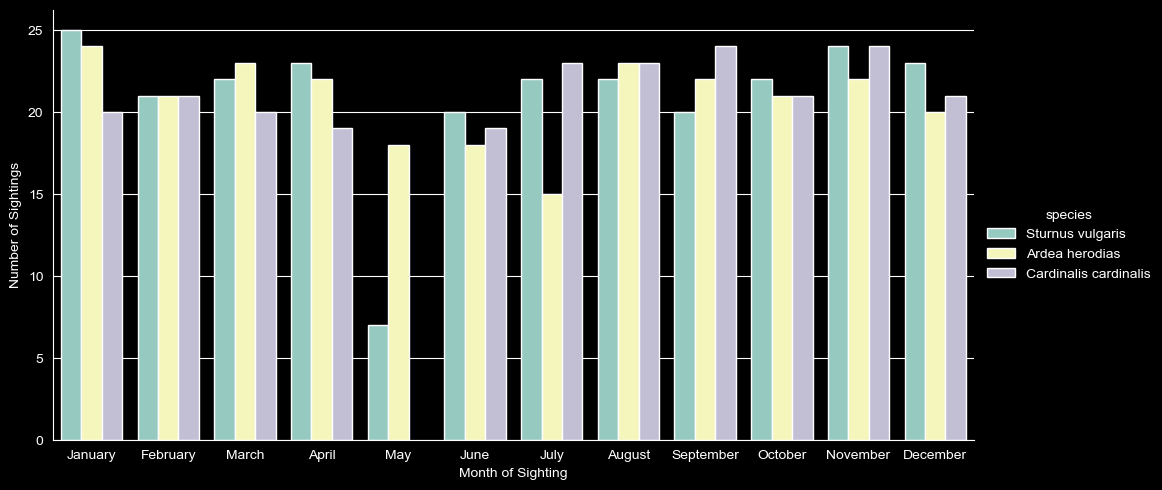

In [9]:
calculate_analysis(com_df)

In [10]:
com_df.groupby(by=["species","month"], as_index=False, dropna=True).size()

,species,month,size
0,Ardea herodias,1,24
1,Ardea herodias,2,21
2,Ardea herodias,3,23
3,Ardea herodias,4,22
4,Ardea herodias,5,18
5,Ardea herodias,6,18
6,Ardea herodias,7,15
7,Ardea herodias,8,23
8,Ardea herodias,9,22
9,Ardea herodias,10,21


In [ ]:
# Analysis
from json import loads, dumps

species_list = ["Sturnus_vulgaris", "Ardea_herodias", "Cardinalis_cardinalis"]
state_info = pd.read_csv("state_reference.csv")

data = fetch_gbif_data(species_list, 2023)
clean_data, cleaning_metrics = clean_biodiversity_data(data)
combined_df = enrich_with_state_data(clean_data, state_info)

analysis_df = calculate_analysis(combined_df)
result = analysis_df.to_json(orient="index", compression={"method": "json"})
parsed = loads(result)
dumps(parsed, indent=4)

In [ ]:
# Metrics

cleaning_metrics = clean_biodiversity_data(data)[1]
cleaning_metrics = pd.Series(cleaning_metrics)
result = cleaning_metrics.to_json(orient="index", compression={"method": "json"})
parsed = loads(result)
dumps(parsed, indent=4)